# 06｜Multivariate Process Analysis

## 這一本我想看什麼？

在 05 裡面，我已經看到同一片 wafer 有時候會同時出現好幾個單變量 SPC signals。  
所以到了 06，我不想再一個 sensor 一個 sensor 分開看，而是想確認：

> **這些一起變動的 process signals，會不會其實是在反映同一個比較大的 multivariate process pattern？另外，把 wafer sequence 的線性趨勢扣掉之後，這些共同結構還剩多少？**

這一本直接接前面的結果：

- `03 → process_wafer_summary.csv`：每片 wafer 的 canonical Main Active Window summary
- `05 → spc_sequence_adjusted_residuals.csv`：每個 sensor 扣掉 Lot 內 wafer-sequence 線性趨勢後的 residual
- `05 → spc_feature_summary.csv`：每個 sensor 有多少 Lots / wafers 可以有效建立 residual

這裡**不重新切 process window、不重新算 residual，也不使用 Quality target**。  
PCA 在這一本的用途只是整理 process variables 之間的共同變化，不拿來做 supervised prediction。


## 1. 先確認上游檔案都在

第一步先把 03 和 05 已經做好的檔案接進來。  
我希望 06 只負責 multivariate analysis，所以 Main Active Window 和 sequence residual 都直接沿用前面的定義，不在這裡再做第二套。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

process_summary_path = PROCESSED_DATA_DIR / "process_wafer_summary.csv"
spc_residual_path = PROCESSED_DATA_DIR / "spc_sequence_adjusted_residuals.csv"
spc_feature_summary_path = PROCESSED_DATA_DIR / "spc_feature_summary.csv"

required_paths = [
    process_summary_path,
    spc_residual_path,
    spc_feature_summary_path,
]

for path in required_paths:
    print(f"{path.name:<42}", "存在" if path.exists() else "找不到")

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "缺少必要檔案：" + ", ".join(str(path) for path in missing_paths)
    )

print("路徑設定完成")

process_wafer_summary.csv                  存在
spc_sequence_adjusted_residuals.csv        存在
spc_feature_summary.csv                    存在
路徑設定完成


### 1.1 結果怎麼看？

三個需要的檔案都有成功找到，所以 06 可以直接沿用前面的資料定義。

這件事看起來只是路徑檢查，但其實很重要，因為後面我要比較 Raw PCA 和 Residual PCA。如果 06 又自己重切一次 window 或重算 residual，就很難知道差異到底來自 process 本身，還是來自 preprocessing 不一致。

所以到這一步可以先確定：

- 03 負責 Main Active Window；
- 05 負責 sequence-adjusted residual；
- 06 只負責比較兩種 representation 的 multivariate structure。


## 2. 載入 03 的 Process Summary 和 05 的 Residual Data

接著把三個表讀進來，並檢查 wafer 數量、feature 數量和 key 是否能一一對上。  
這一步主要是在確認 Raw representation 和 Residual representation 是建立在同一批 wafers 上，後面才有資格拿來比較。


In [2]:
process_summary = pd.read_csv(process_summary_path)
spc_residuals = pd.read_csv(spc_residual_path)
spc_feature_summary = pd.read_csv(spc_feature_summary_path)

main_mean_columns = [
    column
    for column in process_summary.columns
    if column.startswith("main_mean__")
]


required_residual_columns = {
    "feature", "experiment_key", "lot_number",
    "wafer_number", "residual", "valid_lot"
}
missing_residual_columns = (
    required_residual_columns - set(spc_residuals.columns)
)
if missing_residual_columns:
    raise ValueError(
        "SPC residual schema 缺少："
        + ", ".join(sorted(missing_residual_columns))
    )

if spc_residuals["valid_lot"].dtype != bool:
    bool_map = {
        True: True, False: False, 1: True, 0: False,
        "True": True, "False": False,
        "true": True, "false": False,
    }
    spc_residuals["valid_lot"] = (
        spc_residuals["valid_lot"].map(bool_map)
    )
    if spc_residuals["valid_lot"].isna().any():
        raise ValueError("valid_lot 無法安全轉為 boolean")

assert len(process_summary) == 96
assert process_summary["experiment_key"].is_unique
assert process_summary["lot_number"].nunique() == 10
assert len(main_mean_columns) == 27
assert len(spc_residuals) == 2592
assert len(spc_feature_summary) == 27
assert set(spc_residuals["experiment_key"]) == set(process_summary["experiment_key"])

print("Process Summary Rows：", len(process_summary))
print("Unique Wafers：", process_summary["experiment_key"].nunique())
print("Main Mean Features：", len(main_mean_columns))
print("Residual Records：", len(spc_residuals))
print("SPC Feature Summary Rows：", len(spc_feature_summary))

display(
    process_summary[
        ["experiment_key", "lot_number", "wafer_number", "main_active_duration"]
    ].head(12)
)

Process Summary Rows： 96
Unique Wafers： 96
Main Mean Features： 27
Residual Records： 2592
SPC Feature Summary Rows： 27


,experiment_key,lot_number,wafer_number,main_active_duration
0,2024-07-02_01,1,1,597.8
1,2024-07-02_02,1,2,595.0
2,2024-07-02_03,1,3,598.0
3,2024-07-02_04,1,4,598.0
4,2024-07-02_05,1,5,594.8
5,2024-07-02_06,1,6,598.0
6,2024-07-02_07,1,7,598.0
7,2024-07-02_08,1,8,594.8
8,2024-07-02_09,1,9,598.0
9,2024-07-02_10,1,10,598.0


### 2.1 結果怎麼看？

目前資料對得很完整：

- Process Summary：**96 片 wafers**
- Main-process mean features：**27 個**
- SPC residual records：**2,592 筆 = 27 × 96**
- SPC feature summary：**27 列**
- residual 裡的 `experiment_key` 和 process summary 的 96 片 wafer 完全一致

畫面上的前 12 列只是讓我再看一次 wafer 排序和 Lot / Wafer identity 是否正常，例如 Lot 1 的 Wafer 1～10 接著才進 Lot 2。

所以後面 Raw PCA 和 Residual PCA 雖然使用的 feature universe 不完全一樣，但至少**wafer 母體沒有偷偷換掉**。這樣 PCA 結構有差異時，才能把重點放在「有沒有做 sequence adjustment」和「哪些 features 有效」上。


## 3. PCA 前先排除幾乎不變的 Mean Features

PCA 會先做標準化。如果某個 feature 在 96 片 wafer 上幾乎完全不變，標準化反而可能把很小的浮點誤差放大，所以這裡先用和前面一致的 tolerance 判斷：

- `rtol = 1e-7`
- `atol = 1e-8`

這裡只是在找「Main Active Mean 幾乎不變」的欄位，不代表那個 sensor 在其他 representation 也一定沒資訊。


In [3]:
def short_feature_name(full_feature_name):
    return full_feature_name.replace("Stat3_Etch_MV_", "")

raw_feature_records = []

for column in main_mean_columns:
    feature = column.replace("main_mean__", "")
    values = process_summary[column].to_numpy(dtype=float)

    is_effectively_constant = np.allclose(
        values,
        values[0],
        rtol=1e-7,
        atol=1e-8,
    )

    raw_feature_records.append(
        {
            "column": column,
            "feature": feature,
            "feature_short": short_feature_name(feature),
            "is_effectively_constant": bool(is_effectively_constant),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        }
    )

raw_feature_summary = pd.DataFrame(raw_feature_records)

raw_varying_features = raw_feature_summary.loc[
    ~raw_feature_summary["is_effectively_constant"],
    "feature",
].tolist()

raw_constant_features = raw_feature_summary.loc[
    raw_feature_summary["is_effectively_constant"],
    "feature",
].tolist()

print("All Main Mean Features：", len(raw_feature_summary))
print("Effectively Constant：", len(raw_constant_features))
print("Varying Features for Raw PCA：", len(raw_varying_features))

print("\nConstant Features：")
for feature in raw_constant_features:
    print("-", feature)


All Main Mean Features： 27
Effectively Constant： 2
Varying Features for Raw PCA： 25

Constant Features：
- Stat3_Etch_MV_EpdIntensity
- Stat3_Etch_MV_SourceRFTuningCapacitor


### 3.1 結果怎麼看？

27 個 Main Active Mean features 裡，有 **2 個幾乎是 constant**：

- `EpdIntensity`
- `SourceRFTuningCapacitor`

所以 Raw PCA 最後使用 **25 個 varying features**。

這個結果不能直接說「這兩個 sensors 沒用」。比較準確的說法是：

> **它們的 Main Active Window 平均值在 wafer 之間幾乎沒有變化，所以 mean 這種 representation 對 PCA 幫助不大。**

但它們的 `std`、前後段差異或其他 waveform shape 仍可能有資訊。這也是下一本 07 不會只做 mean features 的原因。


## 4. 先看 Raw Mean Features 之間的相關性

在做 PCA 前，我先用 Pearson correlation 看 25 個 varying Main-Process Means 有沒有很嚴重的線性重複。

這一步只想回答「哪些 signals 常常一起變」，**不是要用 correlation 直接刪 sensor，也不是在做因果判斷**。


Feature Pairs： 300
|r| >= 0.80： 3


,feature_1,feature_2,pearson_r,abs_pearson_r
0,Gas4Flow,Gas5Flow,-0.963929,0.963929
1,PlatenRFPeakToPeak,PlatenRFTuningCapacitor,0.887238,0.887238
2,Gas1Flow,SourceRF2TuningCapacitor,-0.844668,0.844668
3,Gas4Flow,SourceRF2TuningCapacitor,-0.776824,0.776824
4,Gas5Flow,SourceRF2TuningCapacitor,0.772008,0.772008
5,PlatenRFPeakToPeak,moriInnerCurrent,0.704657,0.704657
6,PlatenRFTuningCapacitor,SourceRFLoadPower,-0.698078,0.698078
7,ForeLinePressure,SourceRFPeakToPeak,0.677529,0.677529
8,Gas1Flow,Gas5Flow,-0.673205,0.673205
9,PlatenRFTuningCapacitor,moriInnerCurrent,0.660800,0.660800


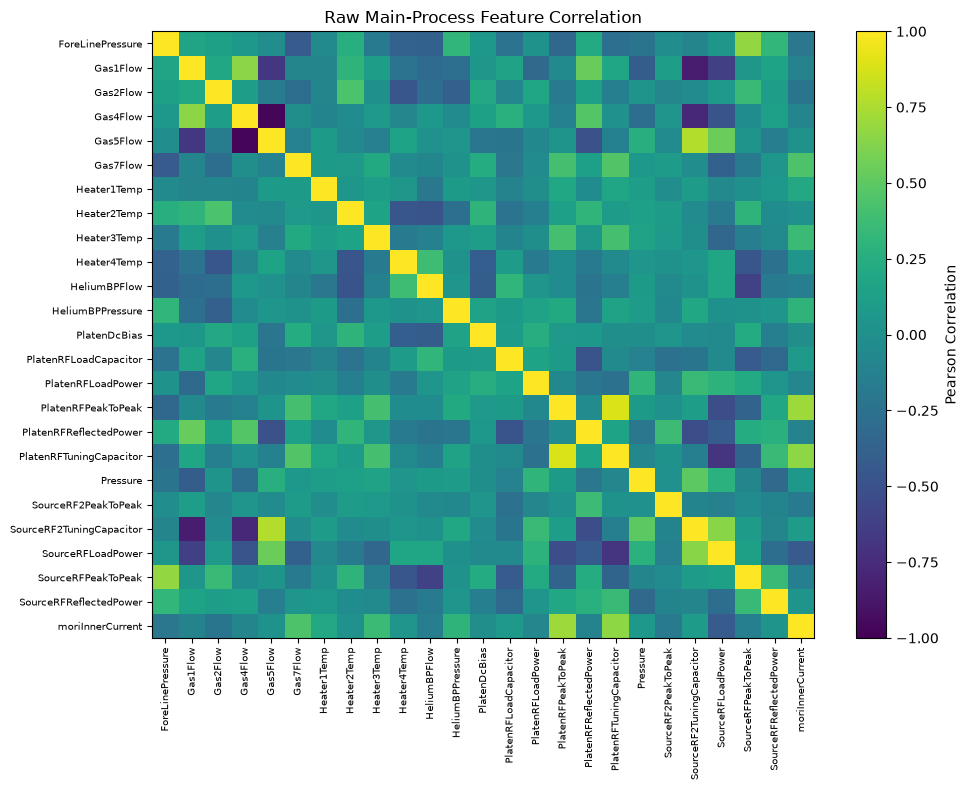

In [4]:
raw_columns = [f"main_mean__{feature}" for feature in raw_varying_features]
raw_short_names = [short_feature_name(feature) for feature in raw_varying_features]

raw_feature_df = process_summary[raw_columns].copy()
raw_feature_df.columns = raw_short_names

raw_correlation = raw_feature_df.corr(method="pearson")

correlation_records = []

for i in range(len(raw_short_names)):
    for j in range(i + 1, len(raw_short_names)):
        r = float(raw_correlation.iloc[i, j])

        correlation_records.append(
            {
                "feature_1": raw_short_names[i],
                "feature_2": raw_short_names[j],
                "pearson_r": r,
                "abs_pearson_r": abs(r),
            }
        )

raw_correlation_pairs = (
    pd.DataFrame(correlation_records)
    .sort_values("abs_pearson_r", ascending=False)
    .reset_index(drop=True)
)

print("Feature Pairs：", len(raw_correlation_pairs))
print(
    "|r| >= 0.80：",
    int((raw_correlation_pairs["abs_pearson_r"] >= 0.80).sum()),
)

display(raw_correlation_pairs.head(15))

plt.figure(figsize=(10, 8))

image = plt.imshow(
    raw_correlation.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

plt.colorbar(image, label="Pearson Correlation")

plt.xticks(
    np.arange(len(raw_short_names)),
    raw_short_names,
    rotation=90,
    fontsize=7,
)

plt.yticks(
    np.arange(len(raw_short_names)),
    raw_short_names,
    fontsize=7,
)

plt.title("Raw Main-Process Feature Correlation")
plt.tight_layout()
plt.show()


### 4.1 表格和 Heatmap 怎麼看？

25 個 features 一共有 **300 組 pair**，但只有 **3 組**達到 `|r| >= 0.80`：

- `Gas4Flow ↔ Gas5Flow`：約 **-0.964**
- `PlatenRFPeakToPeak ↔ PlatenRFTuningCapacitor`：約 **+0.887**
- `Gas1Flow ↔ SourceRF2TuningCapacitor`：約 **-0.845**

Heatmap 也看得出來，多數非對角線格子沒有非常深，代表整個 process matrix 並不是「每個 sensor 都在量同一件事」。比較像是**少數區塊有明顯聯動，但整體仍保留很多不同方向的 variation**。

最明顯的是 Gas 和部分 RF signals。例如 `Gas4Flow` 和 `Gas5Flow` 幾乎是反方向一起動。

這一步對下一步的意義是：  
我不適合只靠 pairwise correlation 大量刪欄位，因為 redundancy 並不是全面性的。用 PCA 去看多個 variables 一起變動的方向會比較合理。

另外，這裡還是 Raw Mean，所以 correlation 可能混著 Lot effect、wafer sequence 或其他共同 process state，不能直接當作設備物理耦合。


## 5. Raw Process PCA

接下來對 25 個 varying mean features 做 PCA。因為不同 sensors 的單位和尺度差很多，所以先用 `StandardScaler` 把每個 feature 標準化。

這一版 Raw PCA 還沒有扣掉 sequence，因此裡面可能同時混著：

- Lot 之間的 process level 差異
- Lot 內 wafer sequence drift
- sensors 之間的共同變化
- 其他沒有直接觀測到的 process state

所以這一步先看「原始 multivariate structure 長什麼樣」，後面才和 residual PCA 比。


In [5]:
raw_scaler = StandardScaler()
raw_z = raw_scaler.fit_transform(raw_feature_df)

raw_pca = PCA()
raw_scores = raw_pca.fit_transform(raw_z)

raw_explained_variance = raw_pca.explained_variance_ratio_
raw_cumulative_variance = np.cumsum(raw_explained_variance)

raw_pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(raw_explained_variance) + 1),
        "explained_variance_ratio": raw_explained_variance,
        "cumulative_variance_ratio": raw_cumulative_variance,
    }
)

def components_needed(cumulative_variance, target):
    return int(np.searchsorted(cumulative_variance, target) + 1)

print("PC1 Explained Variance：", round(raw_explained_variance[0] * 100, 2), "%")
print("PC2 Explained Variance：", round(raw_explained_variance[1] * 100, 2), "%")
print("PC3 Explained Variance：", round(raw_explained_variance[2] * 100, 2), "%")
print("First 3 PCs Cumulative：", round(raw_cumulative_variance[2] * 100, 2), "%")

for target in [0.80, 0.90, 0.95]:
    print(
        f"PCs for {int(target * 100)}%：",
        components_needed(raw_cumulative_variance, target),
    )

display(raw_pca_variance.head(15))


PC1 Explained Variance： 19.83 %
PC2 Explained Variance： 16.15 %
PC3 Explained Variance： 12.9 %
First 3 PCs Cumulative： 48.88 %
PCs for 80%： 9
PCs for 90%： 12
PCs for 95%： 15


,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.198306,0.198306
1,2,0.161548,0.359854
2,3,0.128986,0.488839
3,4,0.079536,0.568375
4,5,0.073844,0.642219
5,6,0.056262,0.698481
6,7,0.048535,0.747016
7,8,0.040070,0.787087
8,9,0.039137,0.826224
9,10,0.031150,0.857374


### 5.1 PCA 數字怎麼看？

Raw PCA 的前 3 個 components 分別解釋：

- PC1：**19.83%**
- PC2：**16.15%**
- PC3：**12.90%**
- 前 3 個加起來：**48.88%**

也就是說，前 3 個主要方向已經可以整理接近一半的 process variation，但**還不到可以用 2～3 個 PCs 就代表整個製程**的程度。

如果希望保留：

- 80% variation：需要 **9 PCs**
- 90%：需要 **12 PCs**
- 95%：需要 **15 PCs**

所以這份資料確實有共同結構，但 process 仍然是多維的。  
我會把 PCA 當成「幫我整理共同變化和 redundancy 的工具」，而不是直接把 PC1～PC3 當成全部 process information。


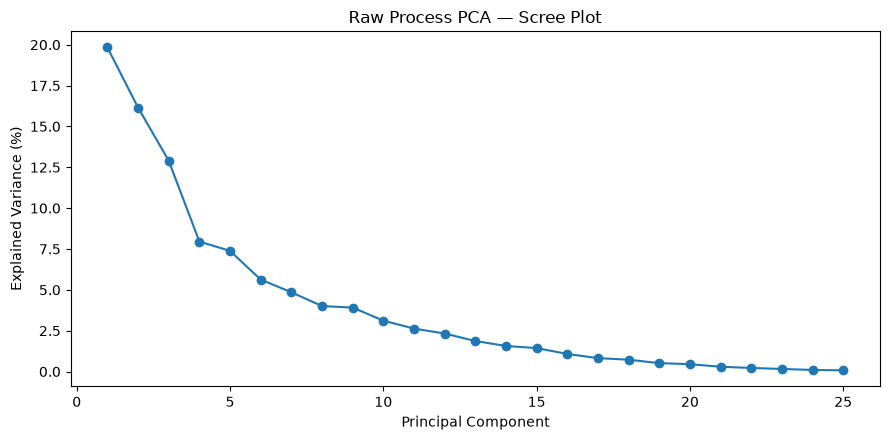

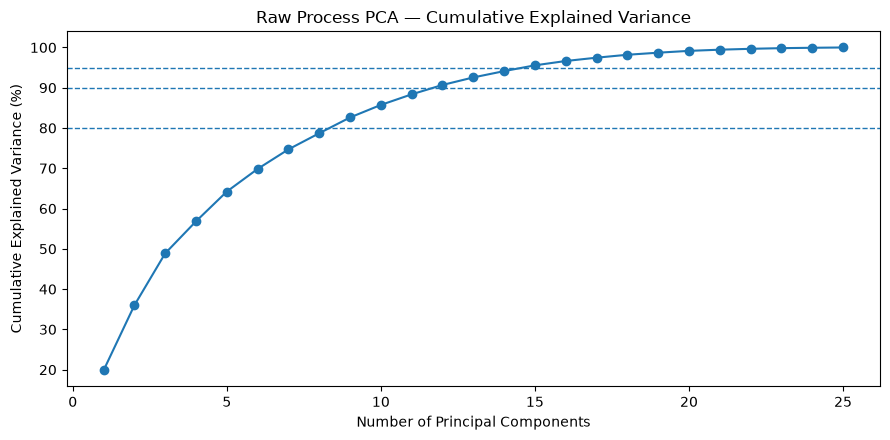

In [6]:
plt.figure(figsize=(9, 4.5))

plt.plot(
    raw_pca_variance["component"],
    raw_pca_variance["explained_variance_ratio"] * 100,
    marker="o",
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Raw Process PCA — Scree Plot")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4.5))

plt.plot(
    raw_pca_variance["component"],
    raw_pca_variance["cumulative_variance_ratio"] * 100,
    marker="o",
)

for threshold in [80, 90, 95]:
    plt.axhline(threshold, linestyle="--", linewidth=1)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Raw Process PCA — Cumulative Explained Variance")
plt.tight_layout()
plt.show()


### 5.2 兩張 PCA 圖怎麼看？

**Scree plot** 前面掉得比較快，尤其 PC1～PC3 最明顯；到了 PC4 之後曲線開始變平。不過後面的 PCs 仍然各自解釋一些 variation，所以沒有非常乾淨的 sharp elbow 可以說「留 2～3 個就夠了」。

**Cumulative plot** 更直接：

- 3 PCs：約 **48.9%**
- 8 PCs：約 **78.7%**
- 第 9 個 PC 才超過 80%
- 第 12 個才超過 90%
- 第 15 個才超過 95%

所以這兩張圖合起來的意思是：

> **PCA 可以把前幾個共同方向抓出來，但整個 process variation 沒有被壓成很低維的結構。**

這也提醒我，後面做 supervised model 時不能只因為前幾個 PCs 看起來重要，就直接丟掉其他原始 process features。


## 6. 看 Raw PCA 的 Component Weights

接著看 PC1～PC3 主要是由哪些 sensors 組成。

這裡看的是 `PCA.components_` 的權重。PCA 的整個 component 正負號可以一起翻轉，所以**正號不是好、負號也不是壞**；真正有意義的是 absolute weight 大小，以及同一個 PC 裡哪些 variables 在相反方向。


In [7]:
raw_component_weights = pd.DataFrame(
    raw_pca.components_.T,
    index=raw_short_names,
    columns=[f"PC{i}" for i in range(1, len(raw_short_names) + 1)],
)

def top_component_weights(component_weight_df, component, top_n=8):
    result = component_weight_df[[component]].copy()
    result["abs_weight"] = result[component].abs()

    return (
        result
        .sort_values("abs_weight", ascending=False)
        .head(top_n)
    )

for component in ["PC1", "PC2", "PC3"]:
    print("\n", component)
    display(
        top_component_weights(
            raw_component_weights,
            component,
            top_n=8,
        )
    )



 PC1


,PC1,abs_weight
Gas1Flow,0.386199,0.386199
SourceRF2TuningCapacitor,-0.367751,0.367751
SourceRFLoadPower,-0.360360,0.360360
Gas5Flow,-0.352158,0.352158
Gas4Flow,0.324658,0.324658
PlatenRFReflectedPower,0.314710,0.314710
Pressure,-0.196643,0.196643
PlatenRFTuningCapacitor,0.183474,0.183474



 PC2


,PC2,abs_weight
PlatenRFPeakToPeak,0.402485,0.402485
PlatenRFTuningCapacitor,0.384414,0.384414
moriInnerCurrent,0.356062,0.356062
SourceRFPeakToPeak,-0.340891,0.340891
ForeLinePressure,-0.308050,0.308050
Gas7Flow,0.275623,0.275623
Gas2Flow,-0.243813,0.243813
SourceRFLoadPower,-0.228383,0.228383



 PC3


,PC3,abs_weight
HeliumBPFlow,0.362802,0.362802
PlatenRFLoadCapacitor,0.299101,0.299101
Heater2Temp,-0.296143,0.296143
SourceRFPeakToPeak,-0.294933,0.294933
Heater4Temp,0.280554,0.280554
SourceRF2TuningCapacitor,-0.273950,0.273950
Gas4Flow,0.261172,0.261172
PlatenRFPeakToPeak,-0.204119,0.204119


### 6.1 前三個 PCs 主要在反映什麼？

**PC1** 最大的權重主要來自：

- `Gas1Flow` +0.386
- `Gas4Flow` +0.325
- `PlatenRFReflectedPower` +0.315
- `SourceRF2TuningCapacitor` -0.368
- `SourceRFLoadPower` -0.360
- `Gas5Flow` -0.352

所以 PC1 比較像是 **Gas1 / Gas4 / Platen reflected power** 和 **Source RF / Gas5** 之間的一個共同對比，不是某一個 sensor 單獨決定。

**PC2** 的大權重集中在：

- `PlatenRFPeakToPeak` +0.402
- `PlatenRFTuningCapacitor` +0.384
- `moriInnerCurrent` +0.356
- `SourceRFPeakToPeak` -0.341
- `ForeLinePressure` -0.308

所以 PC2 比較像 Platen-RF / current 和 Source-RF / foreline 的共同方向。

**PC3** 則比較混合，包含 Helium、Platen RF load、Heater、Source RF 和 Gas4。

我不會硬把這些 PC 命名成單一物理機制，因為每個 component 都是多個 sensor 組合出來的。這裡比較有意義的結論是：

> **Raw process 的主要 multivariate directions 是跨 sensor family 一起形成的。**


## 7. Raw PCA Scores：看看 Lot 和 Wafer Sequence 有沒有留下結構

前面只看 PC 的 variance 和 weights，還不知道 wafer 在 PCA space 裡怎麼分布。

這一步把每片 wafer 投影到 PC1、PC2，再用 Lot 顏色標出來，先從圖上看不同 Lots 有沒有聚在不同區域。


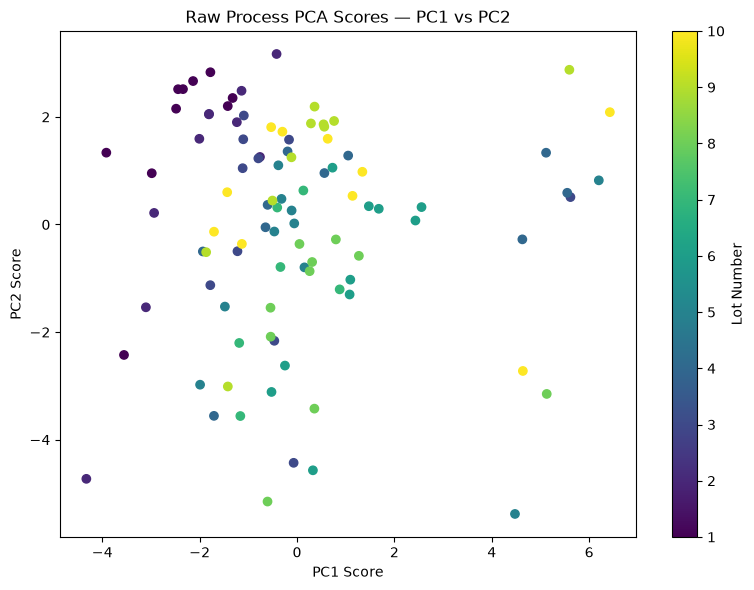

In [8]:
raw_score_columns = [f"PC{i}" for i in range(1, raw_scores.shape[1] + 1)]

raw_pca_scores = pd.DataFrame(
    raw_scores,
    columns=raw_score_columns,
)

raw_pca_scores["experiment_key"] = process_summary["experiment_key"].to_numpy()
raw_pca_scores["lot_number"] = process_summary["lot_number"].to_numpy()
raw_pca_scores["wafer_number"] = process_summary["wafer_number"].to_numpy()

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    raw_pca_scores["PC1"],
    raw_pca_scores["PC2"],
    c=raw_pca_scores["lot_number"],
)

plt.colorbar(scatter, label="Lot Number")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.title("Raw Process PCA Scores — PC1 vs PC2")
plt.tight_layout()
plt.show()


### 7.1 PC1–PC2 Scatter 怎麼看？

圖上可以看到一些 Lot structure，但不是乾淨分成 10 群。

我的觀察是：

- 某些 Lot 的點比較常落在特定區域，所以 Lot information 不是完全沒有；
- 但不同顏色也大量重疊，表示只靠 PC1、PC2 無法把 Lots 清楚切開；
- 有少數 wafers 落在比較遠的位置，例如 PC1 約 5～6 或 PC2 約 -4～-5，代表它們在 Raw multivariate space 比較極端；
- 但 PC1 + PC2 只解釋約 **36%** variation，所以這張 2D 圖不能直接拿來判斷 anomaly。

因此我不會只靠這張 scatter 說「Lot effect 很強」或「有某片 wafer 異常」。比較合理的是再把 Lot effect 和 Lot 內 sequence effect 分開量化。


## 7.2 把圖上的 Lot / Sequence Pattern 用數字拆開

只看 scatter 很容易受到視覺影響，所以這一步多算兩個 descriptive 指標：

- `lot_eta_squared`：每個 PC score 的 variation 有多少可以用不同 Lot 的中心差異描述；
- within-lot Spearman：在同一個 Lot 裡，PC score 會不會跟 wafer number 一起上升或下降。

這裡只是整理 structure，不做顯著性檢定，也不把 association 當成因果。


In [9]:
def eta_squared(groups, values):
    groups = np.asarray(groups)
    values = np.asarray(values, dtype=float)

    grand_mean = float(np.mean(values))
    ss_total = float(np.sum((values - grand_mean) ** 2))

    if ss_total <= 0:
        return np.nan

    ss_between = 0.0

    for group_value in np.unique(groups):
        group_values = values[groups == group_value]

        ss_between += (
            len(group_values)
            * (np.mean(group_values) - grand_mean) ** 2
        )

    return ss_between / ss_total


raw_pc_structure_records = []

for component in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    lot_rhos = []

    for lot_number, group in raw_pca_scores.groupby("lot_number"):
        rho = group["wafer_number"].corr(
            group[component],
            method="spearman",
        )

        lot_rhos.append(rho)

    component_number = int(component.replace("PC", ""))

    raw_pc_structure_records.append(
        {
            "component": component,
            "explained_variance_pct": 100 * raw_explained_variance[component_number - 1],
            "lot_eta_squared": eta_squared(
                raw_pca_scores["lot_number"],
                raw_pca_scores[component],
            ),
            "median_within_lot_spearman": float(np.nanmedian(lot_rhos)),
            "median_abs_within_lot_spearman": float(np.nanmedian(np.abs(lot_rhos))),
            "positive_spearman_lots": int(np.sum(np.asarray(lot_rhos) > 0)),
            "negative_spearman_lots": int(np.sum(np.asarray(lot_rhos) < 0)),
        }
    )

raw_pc_structure = pd.DataFrame(raw_pc_structure_records)
display(raw_pc_structure)


,component,explained_variance_pct,lot_eta_squared,median_within_lot_spearman,median_abs_within_lot_spearman,positive_spearman_lots,negative_spearman_lots
0,PC1,19.830613,0.298058,0.541126,0.541126,9,1
1,PC2,16.154764,0.284225,0.939394,0.939394,9,1
2,PC3,12.898553,0.547095,-0.606061,0.606061,1,9
3,PC4,7.953598,0.291782,-0.181818,0.181818,2,8
4,PC5,7.384404,0.781819,0.284848,0.284848,10,0


### 7.3 量化後可以看到什麼？

這張表很有用，因為它把 **between-Lot** 和 **within-Lot sequence** 分開了。

**PC2 最像 sequence axis：**

- median within-lot Spearman ≈ **+0.939**
- 10 個 Lots 裡有 **9 個是正方向**
- Lot eta² ≈ **0.284**

也就是說，PC2 很一致地跟著 Lot 內 wafer number 往上走，但它不是最強的 Lot 分群方向。

**PC3 同時有 Lot 和 sequence：**

- median Spearman ≈ **-0.606**
- **9/10 Lots** 是負方向
- Lot eta² ≈ **0.547**

所以 PC3 一方面有明顯的 Lot center difference，一方面在很多 Lots 裡又會隨 wafer number 往下。

**PC5 則比較像 between-Lot axis：**

- Lot eta² ≈ **0.782**
- median within-lot Spearman 只有約 **+0.285**

換句話說，不同 PCs 在抓不同東西：有的比較像 Lot 內 sequence，有的比較像 Lot 之間的 state difference。

這也是我下一步一定要看 residual representation 的原因，因為 Raw PCA 不能把這兩種來源分開。


## 8. 建立 Sequence-Adjusted Residual PCA Dataset

現在改用 05 已經算好的 residual。

05 的做法是每個 Lot、每個 feature 各自做：

`Feature ~ Wafer Number`

而且模型有 intercept，所以 residual 代表：

> **每片 wafer 相對於自己那個 Lot 的線性 fitted trend，偏離了多少。**

這代表 residualization 不只拿掉 slope，也把每個 Lot 自己的 fitted baseline 一起扣掉，因此 Lot 之間的平均 level 差異本來就不會保留在這個 residual representation 裡。

為了不要人工補值，我這裡只保留：

- **10/10 Lots 都能有效算 residual**
- **96/96 wafers 都有 residual**

的 features。

所以 `SourceRF2TuningCapacitor` 只有 6 個 valid Lots，不放進 Residual PCA；另外兩個完全 flat 的 mean features 也不會進來。


In [10]:
residual_pca_features = spc_feature_summary.loc[
    (spc_feature_summary["valid_lots"] == 10)
    & (spc_feature_summary["n_valid_wafers"] == 96),
    "feature",
].tolist()

excluded_from_residual_pca = spc_feature_summary.loc[
    ~spc_feature_summary["feature"].isin(residual_pca_features),
    ["feature", "valid_lots", "n_valid_wafers"],
].copy()

residual_long = spc_residuals[
    spc_residuals["valid_lot"].astype(bool)
    & spc_residuals["feature"].isin(residual_pca_features)
].copy()

residual_matrix = residual_long.pivot(
    index="experiment_key",
    columns="feature",
    values="residual",
)

wafer_order = process_summary["experiment_key"].tolist()
residual_matrix = residual_matrix.reindex(wafer_order)

if residual_matrix.isna().any().any():
    raise ValueError(
        "Residual PCA Matrix 出現缺失值；不應直接做 PCA。"
    )

print("Residual PCA Features：", len(residual_pca_features))
print("Residual PCA Wafers：", len(residual_matrix))
print("Missing Values：", int(residual_matrix.isna().sum().sum()))

print("\nExcluded Features：")
display(excluded_from_residual_pca)


Residual PCA Features： 24
Residual PCA Wafers： 96
Missing Values： 0

Excluded Features：


,feature,valid_lots,n_valid_wafers
6,Stat3_Etch_MV_SourceRF2TuningCapacitor,6,60
25,Stat3_Etch_MV_EpdIntensity,0,0
26,Stat3_Etch_MV_SourceRFTuningCapacitor,0,0


### 8.1 Residual PCA 的資料最後長什麼樣？

最後是：

- **96 wafers**
- **24 個 residual features**
- **0 個 missing value**

被排除的 3 個 features 是：

- `SourceRF2TuningCapacitor`：只有 6/10 Lots、60/96 wafers 有有效 residual
- `EpdIntensity`：0 個 valid Lots
- `SourceRFTuningCapacitor`：0 個 valid Lots

我寧願少用 3 個 features，也不要為了湊成矩陣把 invalid residual 補成 0。

另外要注意，Raw PCA 用 25 個 features、Residual PCA 用 24 個，所以**Raw PC1 和 Residual PC1 不是同一條軸**，後面不能直接用 component 編號做一對一物理解讀。


## 9. 看 Sequence-Adjusted Residual 的相關性

把 Lot-specific linear sequence trend 扣掉後，再看 residual features 之間是不是還會一起變。

如果某些 correlation 還很高，代表目前這個簡單的 linear sequence adjustment 沒有把它們的共同 structure 解釋完。


In [11]:
residual_short_names = [
    short_feature_name(feature)
    for feature in residual_matrix.columns
]

residual_feature_df = residual_matrix.copy()
residual_feature_df.columns = residual_short_names

residual_correlation = residual_feature_df.corr(method="pearson")

residual_corr_records = []

for i in range(len(residual_short_names)):
    for j in range(i + 1, len(residual_short_names)):
        r = float(residual_correlation.iloc[i, j])

        residual_corr_records.append(
            {
                "feature_1": residual_short_names[i],
                "feature_2": residual_short_names[j],
                "pearson_r": r,
                "abs_pearson_r": abs(r),
            }
        )

residual_correlation_pairs = (
    pd.DataFrame(residual_corr_records)
    .sort_values("abs_pearson_r", ascending=False)
    .reset_index(drop=True)
)

display(residual_correlation_pairs.head(15))


,feature_1,feature_2,pearson_r,abs_pearson_r
0,Gas4Flow,Gas5Flow,-0.974100,0.974100
1,Gas1Flow,Gas4Flow,0.768791,0.768791
2,Gas1Flow,Gas5Flow,-0.763561,0.763561
3,Gas1Flow,SourceRFLoadPower,-0.743622,0.743622
4,PlatenRFPeakToPeak,PlatenRFTuningCapacitor,0.743153,0.743153
5,ForeLinePressure,PlatenRFTuningCapacitor,-0.728191,0.728191
6,ForeLinePressure,PlatenRFPeakToPeak,-0.713225,0.713225
7,Gas5Flow,SourceRFLoadPower,0.697400,0.697400
8,Gas4Flow,SourceRFLoadPower,-0.689264,0.689264
9,SourceRFPeakToPeak,SourceRFReflectedPower,0.669656,0.669656


### 9.1 Residual correlation 告訴我什麼？

最強的 pair 還是：

- `Gas4Flow ↔ Gas5Flow` ≈ **-0.974**

Raw 時大約是 -0.964，扣掉每個 Lot 的線性 wafer-sequence trend 後反而仍然非常強。

這裡我不會說「已經證明和 sequence 無關」，因為現在只移除了**線性** sequence pattern。還是可能存在 nonlinear sequence、recipe control logic、latent process state 或其他共同因素。

另外可以看到兩個比較明顯的群：

**Gas / Source-RF：**

- `Gas1Flow ↔ Gas4Flow` ≈ +0.769
- `Gas1Flow ↔ Gas5Flow` ≈ -0.764
- `Gas1Flow ↔ SourceRFLoadPower` ≈ -0.744
- `Gas5Flow ↔ SourceRFLoadPower` ≈ +0.697
- `Gas4Flow ↔ SourceRFLoadPower` ≈ -0.689

**Platen-RF / Foreline：**

- `PlatenRFPeakToPeak ↔ PlatenRFTuningCapacitor` ≈ +0.743
- `ForeLinePressure ↔ PlatenRFTuningCapacitor` ≈ -0.728
- `ForeLinePressure ↔ PlatenRFPeakToPeak` ≈ -0.713

所以 05 裡一片 wafer 同時被多個單變量 rules flag 到，不一定代表「很多獨立問題同時發生」，也可能只是同一個 multivariate state 在不同 sensors 上一起表現出來。


## 10. 對 Residual Features 做 PCA

前面已經知道 residual features 之間還有不少 shared correlation，所以這一步再用 PCA 看扣掉 linear sequence trend 後，剩下的 joint variation 有多集中。

同樣先標準化，再看 explained variance 和 cumulative variance。


In [12]:
residual_scaler = StandardScaler()
residual_z = residual_scaler.fit_transform(residual_feature_df)

residual_pca = PCA()
residual_scores = residual_pca.fit_transform(residual_z)

residual_explained_variance = residual_pca.explained_variance_ratio_
residual_cumulative_variance = np.cumsum(residual_explained_variance)

residual_pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(residual_explained_variance) + 1),
        "explained_variance_ratio": residual_explained_variance,
        "cumulative_variance_ratio": residual_cumulative_variance,
    }
)

print(
    "Residual PC1 Explained Variance：",
    round(residual_explained_variance[0] * 100, 2),
    "%",
)
print(
    "Residual PC2 Explained Variance：",
    round(residual_explained_variance[1] * 100, 2),
    "%",
)
print(
    "Residual PC3 Explained Variance：",
    round(residual_explained_variance[2] * 100, 2),
    "%",
)
print(
    "First 3 Residual PCs Cumulative：",
    round(residual_cumulative_variance[2] * 100, 2),
    "%",
)

for target in [0.80, 0.90, 0.95]:
    print(
        f"Residual PCs for {int(target * 100)}%：",
        components_needed(residual_cumulative_variance, target),
    )

display(residual_pca_variance.head(15))


Residual PC1 Explained Variance： 20.6 %
Residual PC2 Explained Variance： 18.91 %
Residual PC3 Explained Variance： 13.24 %
First 3 Residual PCs Cumulative： 52.75 %
Residual PCs for 80%： 8
Residual PCs for 90%： 12
Residual PCs for 95%： 15


,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.206011,0.206011
1,2,0.189115,0.395126
2,3,0.132351,0.527478
3,4,0.078196,0.605674
4,5,0.074218,0.679891
5,6,0.053888,0.733779
6,7,0.042939,0.776718
7,8,0.038326,0.815044
8,9,0.031648,0.846692
9,10,0.029996,0.876689


### 10.1 Residual PCA 的數字怎麼看？

Residual PCA：

- PC1：**20.60%**
- PC2：**18.91%**
- PC3：**13.24%**
- 前 3 PCs：**52.75%**

要保留：

- 80% variation：**8 PCs**
- 90%：**12 PCs**
- 95%：**15 PCs**

所以把 Lot-specific linear sequence trend 扣掉之後，剩下的 process variation 還是分散在很多方向，並沒有縮成單一 latent axis。

另外不要把「52.75% 比 Raw 的 48.88% 高」解讀成 Residual PCA 比 Raw PCA 好。兩邊 feature 數不同，而且 PCA 會重新旋轉。  
要判斷 detrending 有沒有真的削弱 sequence，後面第 13 節會直接對同一批 24 features 做前後比較。


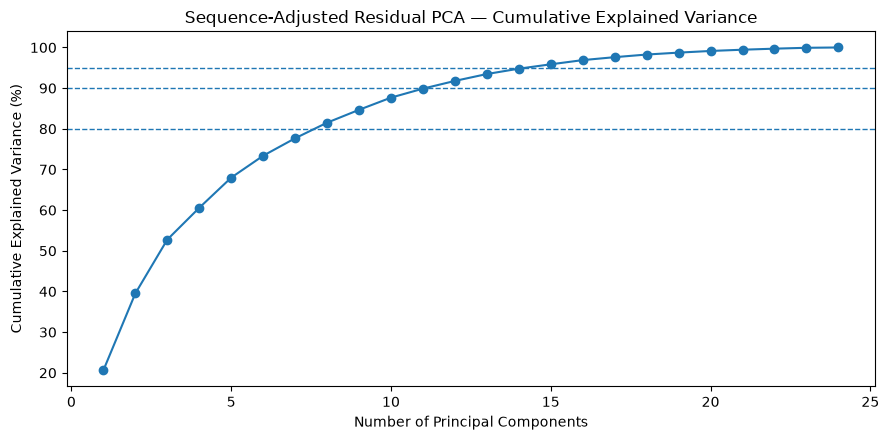

In [13]:
plt.figure(figsize=(9, 4.5))

plt.plot(
    residual_pca_variance["component"],
    residual_pca_variance["cumulative_variance_ratio"] * 100,
    marker="o",
)

for threshold in [80, 90, 95]:
    plt.axhline(threshold, linestyle="--", linewidth=1)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Sequence-Adjusted Residual PCA — Cumulative Explained Variance")
plt.tight_layout()
plt.show()


### 10.2 Cumulative Plot 怎麼看？

Residual PCA 到第 **8 個 PC** 才超過 80% cumulative variance。

這表示扣掉簡單 linear sequence trend 之後，剩下的 variation 仍然是多維的。  
所以如果之後要做 anomaly detection，也不適合只拿 Residual PC1 當「整體異常分數」，因為那只看到了約五分之一的 residual variation。


## 11. 看 Residual PCA 的 Component Weights

這一步和 Raw PCA 一樣，看看 Residual PC1～PC3 主要由哪些 sensors 一起組成。

一樣只看 absolute weight 和同一 component 裡的相對方向，不把 PCA 的正負號當成好壞。


In [14]:
residual_component_weights = pd.DataFrame(
    residual_pca.components_.T,
    index=residual_short_names,
    columns=[f"PC{i}" for i in range(1, len(residual_short_names) + 1)],
)

for component in ["PC1", "PC2", "PC3"]:
    print("\n", component)

    display(
        top_component_weights(
            residual_component_weights,
            component,
            top_n=8,
        )
    )



 PC1


,PC1,abs_weight
PlatenRFPeakToPeak,0.396314,0.396314
ForeLinePressure,-0.347694,0.347694
moriInnerCurrent,0.344541,0.344541
PlatenRFTuningCapacitor,0.332033,0.332033
PlatenDcBias,0.316394,0.316394
HeliumBPPressure,0.306818,0.306818
Gas7Flow,0.293555,0.293555
Gas2Flow,-0.210355,0.210355



 PC2


,PC2,abs_weight
SourceRFLoadPower,0.411643,0.411643
Gas1Flow,-0.408343,0.408343
Gas5Flow,0.403309,0.403309
Gas4Flow,-0.401080,0.401080
PlatenRFReflectedPower,-0.341305,0.341305
Pressure,0.221830,0.221830
PlatenRFTuningCapacitor,-0.210280,0.210280
HeliumBPPressure,0.147627,0.147627



 PC3


,PC3,abs_weight
PlatenRFLoadCapacitor,0.412025,0.412025
Heater4Temp,0.347030,0.347030
Heater2Temp,0.345508,0.345508
Gas2Flow,0.285843,0.285843
Gas7Flow,-0.280471,0.280471
SourceRFPeakToPeak,-0.252783,0.252783
SourceRFReflectedPower,-0.249255,0.249255
SourceRF2PeakToPeak,-0.200526,0.200526


### 11.1 扣掉 sequence 後，主要 joint directions 是什麼？

**Residual PC1** 比較明顯的是：

- `PlatenRFPeakToPeak` +0.396
- `moriInnerCurrent` +0.345
- `PlatenRFTuningCapacitor` +0.332
- `PlatenDcBias` +0.316
- `HeliumBPPressure` +0.307
- `ForeLinePressure` -0.348

所以它比較像 Platen-RF / current / pressure 和 Foreline 的共同對比。

**Residual PC2**：

- `SourceRFLoadPower` +0.412
- `Gas5Flow` +0.403
- `Gas1Flow` -0.408
- `Gas4Flow` -0.401
- `PlatenRFReflectedPower` -0.341

這和前面的 residual correlation 很一致，特別是 Gas4、Gas5 在相反方向，而且 Gas flows 跟 Source RF Load Power 一起形成很強的共同變化。

**Residual PC3** 則混合了 Platen RF load、Heater2 / Heater4、Gas2 / Gas7 和 Source RF。

所以扣掉 sequence 之後，並不是只剩某一個 sensor 最重要，而是 **RF、gas、pressure、thermal 還是會用不同組合一起變動**。


## 12. 看 Residual PCA Scores

最後把 96 片 wafer 投影到 Residual PC1、PC2，看看扣掉每個 Lot 的 linear trend 之後，wafer 還會不會出現明顯的 multivariate tails。


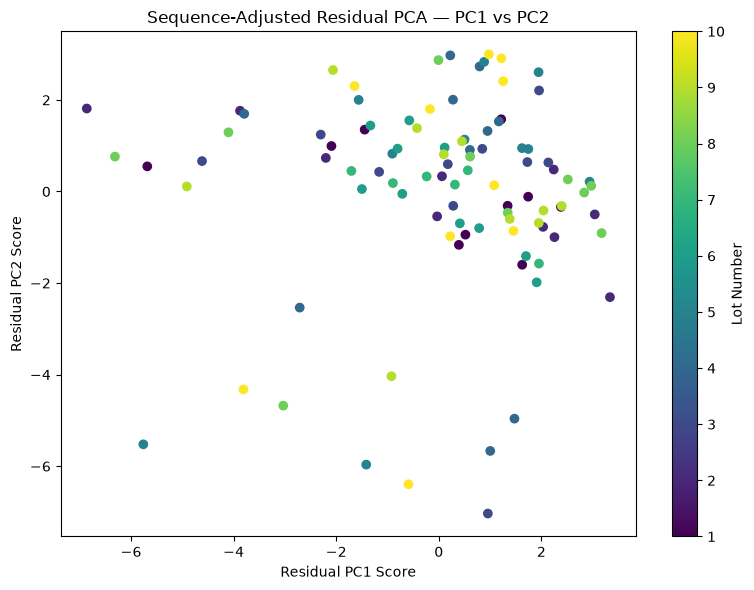

In [15]:
residual_score_columns = [
    f"PC{i}"
    for i in range(1, residual_scores.shape[1] + 1)
]

residual_pca_scores = pd.DataFrame(
    residual_scores,
    columns=residual_score_columns,
)

residual_pca_scores["experiment_key"] = wafer_order

metadata_lookup = process_summary.set_index("experiment_key")

residual_pca_scores["lot_number"] = [
    int(metadata_lookup.loc[key, "lot_number"])
    for key in wafer_order
]

residual_pca_scores["wafer_number"] = [
    int(metadata_lookup.loc[key, "wafer_number"])
    for key in wafer_order
]

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    residual_pca_scores["PC1"],
    residual_pca_scores["PC2"],
    c=residual_pca_scores["lot_number"],
)

plt.colorbar(scatter, label="Lot Number")
plt.xlabel("Residual PC1 Score")
plt.ylabel("Residual PC2 Score")
plt.title("Sequence-Adjusted Residual PCA — PC1 vs PC2")
plt.tight_layout()
plt.show()


### 12.1 Residual PC1–PC2 Scatter 怎麼看？

大多數 wafers 聚在中間，而且不同 Lot 顏色混得比 Raw PCA 更明顯。這和 residualization 後每個 Lot 的 feature mean 會接近 0 是一致的。

但圖上還是有少數點離中央很遠，例如：

- Residual PC1 大約到 **-6～-7**
- Residual PC2 大約到 **-5～-7**

這代表有些 wafers 即使已經扣掉簡單 linear sequence trend，在多個 residual process signals 的聯合方向上還是比較特殊。

不過我這裡只把它們叫 **investigation candidates**，不直接叫 anomalies，因為：

1. PC1 + PC2 只解釋約 **39.5%** residual variation；
2. 這張圖沒有正式 anomaly threshold；
3. PCA 是用全部 96 片 wafers fit 的 descriptive analysis。

所以這張圖最有用的訊息是：**sequence adjustment 沒有把所有 multivariate process variation 都消掉。**


## 13. 用同一批 24 Features 直接比較 Sequence Adjustment 前後

Raw PCA 和 Residual PCA 的 feature 數不同、axes 也不同，所以直接比 Raw PC1 和 Residual PC1 不太公平。

這裡改成比較同一批 24 個 features：  
對每個 feature、每個 Lot 都算它和 `wafer_number` 的 Spearman correlation，再比較 detrending 前後的 absolute correlation。

這樣才是真的在回答：

> **05 的 linear detrending 到底有沒有把 Lot 內的 sequence structure 壓下來？**


In [16]:
feature_sequence_records = []

for feature in residual_pca_features:

    raw_column = f"main_mean__{feature}"

    raw_lot_rhos = []
    residual_lot_rhos = []

    for lot_number in sorted(
        process_summary["lot_number"].unique()
    ):

        raw_group = (
            process_summary[
                process_summary["lot_number"]
                == lot_number
            ]
            .sort_values("wafer_number")
        )

        residual_group = (
            spc_residuals[
                (spc_residuals["feature"] == feature)
                & (spc_residuals["lot_number"] == lot_number)
                & (spc_residuals["valid_lot"].astype(bool))
            ]
            .sort_values("wafer_number")
        )

        raw_rho = (
            raw_group["wafer_number"]
            .corr(
                raw_group[raw_column],
                method="spearman",
            )
        )

        residual_rho = (
            residual_group["wafer_number"]
            .corr(
                residual_group["residual"],
                method="spearman",
            )
        )

        raw_lot_rhos.append(raw_rho)
        residual_lot_rhos.append(residual_rho)


    feature_sequence_records.append(
        {
            "feature":
                short_feature_name(feature),

            "raw_median_abs_within_lot_spearman":
                float(
                    np.nanmedian(
                        np.abs(raw_lot_rhos)
                    )
                ),

            "residual_median_abs_within_lot_spearman":
                float(
                    np.nanmedian(
                        np.abs(residual_lot_rhos)
                    )
                ),

            "raw_median_spearman":
                float(
                    np.nanmedian(
                        raw_lot_rhos
                    )
                ),

            "residual_median_spearman":
                float(
                    np.nanmedian(
                        residual_lot_rhos
                    )
                ),
        }
    )


feature_sequence_comparison = (
    pd.DataFrame(
        feature_sequence_records
    )
    .sort_values(
        "raw_median_abs_within_lot_spearman",
        ascending=False,
    )
    .reset_index(drop=True)
)


raw_overall_median = float(
    feature_sequence_comparison[
        "raw_median_abs_within_lot_spearman"
    ]
    .median()
)


residual_overall_median = float(
    feature_sequence_comparison[
        "residual_median_abs_within_lot_spearman"
    ]
    .median()
)


n_features_reduced = int(
    (
        feature_sequence_comparison[
            "residual_median_abs_within_lot_spearman"
        ]
        <
        feature_sequence_comparison[
            "raw_median_abs_within_lot_spearman"
        ]
    )
    .sum()
)


print(
    "Common Features：",
    len(feature_sequence_comparison),
)

print(
    "Median of Feature-Level Raw "
    "|within-lot Spearman|：",
    round(
        raw_overall_median,
        3,
    ),
)

print(
    "Median of Feature-Level Residual "
    "|within-lot Spearman|：",
    round(
        residual_overall_median,
        3,
    ),
)

print(
    "Features with Reduced Sequence Association：",
    f"{n_features_reduced} / "
    f"{len(feature_sequence_comparison)}",
)


display(
    feature_sequence_comparison.head(15)
)


Common Features： 24
Median of Feature-Level Raw |within-lot Spearman|： 0.388
Median of Feature-Level Residual |within-lot Spearman|： 0.085
Features with Reduced Sequence Association： 24 / 24


,feature,raw_median_abs_within_lot_spearman,residual_median_abs_within_lot_spearman,raw_median_spearman,residual_median_spearman
0,PlatenRFTuningCapacitor,0.957576,0.042424,0.957576,-0.012121
1,SourceRFPeakToPeak,0.806061,0.066667,-0.806061,0.030303
2,ForeLinePressure,0.775758,0.070130,-0.775758,0.042424
3,PlatenRFPeakToPeak,0.769697,0.042424,0.769697,-0.042424
4,SourceRFLoadPower,0.672727,0.072727,-0.672727,-0.030303
5,Gas7Flow,0.557576,0.096970,0.557576,-0.051948
6,Gas2Flow,0.515152,0.042424,0.000000,-0.012121
7,Heater3Temp,0.509091,0.133333,0.418182,-0.036364
8,SourceRFReflectedPower,0.490909,0.048485,0.490909,0.000000
9,PlatenRFLoadPower,0.430303,0.030303,-0.309091,0.012121


### 13.1 這個前後比較很明確

同一批 24 features：

- Raw median `|within-lot Spearman|`：**0.388**
- Residual median：**0.085**
- **24 / 24 features 全部下降**

而且原本 sequence 最強的幾個 features 降得很明顯：

- `PlatenRFTuningCapacitor`：0.958 → **0.042**
- `SourceRFPeakToPeak`：0.806 → **0.067**
- `ForeLinePressure`：0.776 → **0.070**
- `PlatenRFPeakToPeak`：0.770 → **0.042**
- `SourceRFLoadPower`：0.673 → **0.073**

所以 05 的 detrending 不是只有讓數字稍微變小，而是真的把主要的 monotonic wafer-sequence pattern 大幅壓掉。

不過 residual median 不是 0，某些 features 還有大約 0.10～0.13 的 absolute Spearman，所以也不能說 sequence 完全不存在。

綜合前面的 residual correlation 和 PCA，我會把 06 的核心發現寫成：

> **Wafer sequence 是 Raw process variation 的重要來源，但不是唯一來源；把它扣掉後，仍然存在跨 sensors 的 shared multivariate structure。**


## 14. 這些結果要怎麼接到 07？

06 的 PCA 是用完整 96 片 wafers fit 的，所以我不會直接把這裡的 PCA scores 丟到 08 當 predictors。那樣會讓 held-out Lot 參與 preprocessing，產生 leakage。

06 真正告訴下一本的是：

- 只用 mean 會漏掉一些 waveform information；
- process 不是單一低維結構，不能只留 PC1～PC3；
- 某些 mean 幾乎不變，但同一 sensor 的 spread / drift 可能仍有資訊；
- 單變量 SPC flags 之間可能共享 multivariate state。

所以 07 比較合理的做法是回到 Raw trace，但**完全沿用 03 的 canonical Main Active Window**，再建立 mean、std、robust width、early-to-late change 這些容易解釋的 wafer-level features。


## 15. 把 06 的分析結果存成下游可以直接用的檔案

最後把 correlation、PCA variance、component weights、scores、PC structure 和 sequence 前後比較都輸出成 CSV。

這一步不是再做新分析，而是把前面已經確認過的結果固定下來，讓後面的 10、11 可以直接讀，不用重算另一套。


In [17]:
raw_correlation_path = PROCESSED_DATA_DIR / "06_raw_feature_correlation_pairs.csv"
raw_pca_variance_path = PROCESSED_DATA_DIR / "06_raw_pca_variance.csv"
raw_pca_weights_path = PROCESSED_DATA_DIR / "06_raw_pca_component_weights.csv"
raw_pca_scores_path = PROCESSED_DATA_DIR / "06_raw_pca_scores.csv"
raw_pc_structure_path = PROCESSED_DATA_DIR / "06_raw_pc_structure.csv"

residual_correlation_path = PROCESSED_DATA_DIR / "06_residual_feature_correlation_pairs.csv"
residual_pca_variance_path = PROCESSED_DATA_DIR / "06_residual_pca_variance.csv"
residual_pca_weights_path = PROCESSED_DATA_DIR / "06_residual_pca_component_weights.csv"
residual_pca_scores_path = PROCESSED_DATA_DIR / "06_residual_pca_scores.csv"
sequence_comparison_path = PROCESSED_DATA_DIR / "06_feature_sequence_comparison.csv"

raw_correlation_pairs.to_csv(raw_correlation_path, index=False)
raw_pca_variance.to_csv(raw_pca_variance_path, index=False)
raw_component_weights.to_csv(raw_pca_weights_path, index=True, index_label="feature")
raw_pca_scores.to_csv(raw_pca_scores_path, index=False)
raw_pc_structure.to_csv(raw_pc_structure_path, index=False)

residual_correlation_pairs.to_csv(residual_correlation_path, index=False)
residual_pca_variance.to_csv(residual_pca_variance_path, index=False)
residual_component_weights.to_csv(
    residual_pca_weights_path,
    index=True,
    index_label="feature",
)
residual_pca_scores.to_csv(residual_pca_scores_path, index=False)
feature_sequence_comparison.to_csv(sequence_comparison_path, index=False)

output_paths = [
    raw_correlation_path,
    raw_pca_variance_path,
    raw_pca_weights_path,
    raw_pca_scores_path,
    raw_pc_structure_path,
    residual_correlation_path,
    residual_pca_variance_path,
    residual_pca_weights_path,
    residual_pca_scores_path,
    sequence_comparison_path,
]

output_checks = []

for path in output_paths:
    if not path.exists():
        raise FileNotFoundError(f"輸出檔案不存在：{path}")
    reloaded = pd.read_csv(path)
    output_checks.append(
        {
            "file": path.name,
            "rows": len(reloaded),
            "columns": len(reloaded.columns),
        }
    )

assert len(pd.read_csv(raw_pca_scores_path)) == 96
assert len(pd.read_csv(residual_pca_scores_path)) == 96
assert len(pd.read_csv(sequence_comparison_path)) == 24

display(pd.DataFrame(output_checks))

,file,rows,columns
0,06_raw_feature_correlation_pairs.csv,300,4
1,06_raw_pca_variance.csv,25,3
2,06_raw_pca_component_weights.csv,25,26
3,06_raw_pca_scores.csv,96,28
4,06_raw_pc_structure.csv,5,7
5,06_residual_feature_correlation_pairs.csv,276,4
6,06_residual_pca_variance.csv,24,3
7,06_residual_pca_component_weights.csv,24,25
8,06_residual_pca_scores.csv,96,27
9,06_feature_sequence_comparison.csv,24,5


### 15.1 輸出檔案有沒有對上前面的分析？

每個 CSV 的 row count 都和前面的定義一致：

- Raw correlation pairs：**300 = 25×24/2**
- Raw PCA variance：**25 PCs**
- Raw PCA weights：**25 features × 25 PCs**
- Raw PCA scores：**96 wafers**
- Raw PC structure：**前 5 PCs**
- Residual correlation pairs：**276 = 24×23/2**
- Residual PCA variance：**24 PCs**
- Residual PCA weights：**24 features × 24 PCs**
- Residual PCA scores：**96 wafers**
- Sequence comparison：**24 個共同 features**

所以輸出的檔案數量和維度都跟本 notebook 的分析完全對得上。

其中 PCA scores 是 full-data descriptive scores，我只會拿去做 diagnostic / anomaly investigation，**不會直接拿去 08 做 supervised CV predictors**。


# 06｜整份 Notebook 的統整結論

這一本原本想回答的問題是：**05 裡面同一片 wafer 同時出現多個 process signals，背後是不是其實有共同的 multivariate structure？另外，這些結構有多少只是 wafer sequence 造成的？**

跑完後，我的答案是：**有共同 structure，而且 sequence 很重要，但 sequence 並不是全部。**

先看 Raw process。27 個 Main Active Mean features 裡有 2 個幾乎不變，所以 PCA 使用 25 個 varying features。300 組 pair 裡只有 3 組達到 `|r| >= 0.80`，代表 process variables 並不是全面高度重複，而是只有少數 Gas / RF signals 有很強的局部聯動。

Raw PCA 也顯示 process 不算低維：前 3 PCs 只解釋 **48.88%**，要到 **12 PCs** 才超過 90%。把 PCA scores 再拆成 Lot 和 sequence 後，PC2 的 median within-lot Spearman 高達 **0.939**，而 PC5 的 Lot eta² 約 **0.782**。也就是說，Raw multivariate space 同時混著很強的 Lot 內 sequence 和 Lot 間差異。

接著改看 05 的 sequence-adjusted residual。只有 **24 個 features** 能在 10/10 Lots、96/96 wafers 上公平比較。對這 24 個 features，median `|within-lot Spearman|` 從 **0.388 降到 0.085，而且 24/24 全部下降**，所以 05 的 linear detrending 確實有把主要 sequence pattern 壓掉。

但是扣完之後 process structure 還在。像 `Gas4Flow ↔ Gas5Flow` residual correlation 仍然約 **-0.974**；Residual PCA 前 3 PCs 還能解釋 **52.75%**，而且要 **12 PCs** 才超過 90%。Residual PC scatter 也還有少數 wafers 落在很遠的 tails。

所以我不會把 06 的結論寫成「sequence 解釋了所有 process drift」，比較正確的是：

> **Wafer sequence 是一個很重要的共同變化來源，但扣掉 Lot-specific linear trend 後，RF、Gas、Pressure、Thermal 等 signals 之間仍存在明顯的 shared multivariate variation。**

這也決定了 07 的方向：下一步不直接拿 full-data PCA scores 去建模，而是回到相同的 canonical process window，從 Raw trace 建立更多可解釋的 wafer-level features，讓 08 再用嚴格的 group-aware validation 判斷哪些 representation 對 Virtual Metrology 真正有幫助。
